In [19]:
import os, re, sys, glob
import numpy as np, pandas as pd
import h5py, torch
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

RESULTS_DIR = "/grid/koo/home/pmantill/projects/VBI/VAE_gmm/results"
SEAM_DIR    = "/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sys.path.insert(0, "/grid/koo/home/pmantill/projects/VBI/VAE_gmm/benchmark")
from train_grid import VAE_GMM, load_X, parse_config   # same model / library / tag parsing as training
print("device:", DEVICE)

device: cpu


In [20]:
# compare configs by a) cosine silhouette in latent space b) functional coherence of the
# predicted activities c) distance between the cluster centroids
@torch.no_grad()
def quant_eval(ckpt_path):
    tag = os.path.basename(ckpt_path)[:-3]
    peak = tag.split(".100k")[0].split(".200k")[0]
    r = parse_config(re.sub(r"\.?seed\d+$", "", tag[len(peak) + 1:]))
    X = load_X(SEAM_DIR, peak, r["lib"], r["preproc"])
    sd = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)["state_dict"]
    hidden, D = sd["enc.0.weight"].shape                          # hidden width varies across runs
    model = VAE_GMM(D, r["J"], r["K"], r["alpha0"], hidden, np.ones(D, np.float32), r["dropout"], r["bg"])
    model.load_state_dict(sd)
    model.eval().to(DEVICE)
    with h5py.File(f"{SEAM_DIR}/ism{'' if r['lib'] == '100k' else '_200k'}/{peak}.h5") as f:
        y = f["predictions"][:]                                  # model activity of each variant

    # E-step: gamma = softmax_k(E[log pi_k] - KL[q(z|x)||N_k]), analytic in (mu_z, lv_z)
    Elog_pi = torch.digamma(model.alpha) - torch.digamma(model.alpha.sum())
    lv_c, mu_c = model.log_var_c[None], model.mu_c[None]
    Z, hard = [], []
    for i in range(0, len(X), 8192):
        h = model.enc(torch.from_numpy(X[i:i + 8192]).to(DEVICE))
        mu_z, lv_z = model.enc_mu(h)[:, None, :], model.enc_lv(h)[:, None, :]
        KL_k = 0.5 * (lv_c - lv_z + (lv_z.exp() + (mu_z - mu_c) ** 2) * torch.exp(-lv_c) - 1.0).sum(-1)
        Z.append(mu_z[:, 0].cpu().numpy()); hard.append((Elog_pi[None] - KL_k).argmax(1).cpu().numpy())
    Z, hard = np.concatenate(Z), np.concatenate(hard)
    alive = np.unique(hard)

    # (a) cosine silhouette under the hard assignment, in all three spaces the model defines:
    #     latent mu_z (J), decoded foreground decoder(mu_z) (D), and the bg-subtracted data itself (D).
    #     One shared 10k subsample (N ~ 1e5 makes the full pairwise matrix infeasible) so they compare.
    idx = np.random.default_rng(0).choice(len(X), 10000, replace=False)
    dec = model.dec(torch.from_numpy(Z[idx]).to(DEVICE)).cpu().numpy()
    Xfg = X[idx] - model.mu_b.cpu().numpy()
    sil_z   = silhouette_score(Z[idx], hard[idx], metric="cosine")
    sil_dec = silhouette_score(dec,    hard[idx], metric="cosine")
    sil_x   = silhouette_score(Xfg,    hard[idx], metric="cosine")

    # (b) functional coherence: fraction of variance in predicted activity explained by cluster
    within = sum(((y[hard == k] - y[hard == k].mean()) ** 2).sum() for k in alive)
    eta2 = 1 - within / ((y - y.mean()) ** 2).sum()

    # (c) centroid separation: pairwise cosine distance between surviving prototype foregrounds
    proto = model.dec(model.mu_c[torch.as_tensor(alive, device=DEVICE)]).cpu().numpy()
    proto /= np.linalg.norm(proto, axis=1, keepdims=True) + 1e-12
    d = (1 - proto @ proto.T)[np.triu_indices(len(alive), 1)]

    return dict(run=tag, peak=peak, bg=r["bg"], preproc=r["preproc"], J=r["J"], K=r["K"],
                n_clusters=len(alive), sil_cos=float(sil_z), sil_cos_dec=float(sil_dec),
                sil_cos_800d=float(sil_x), func_eta2=float(eta2),
                centroid_dist_mean=float(d.mean()), centroid_dist_min=float(d.min()))

In [21]:
CSV = "results/quant_benchmark.csv"                              # resumable: only new checkpoints are scored
done = pd.read_csv(CSV) if os.path.exists(CSV) else pd.DataFrame(columns=["run"])
rows = []
for p in sorted(glob.glob(f"{RESULTS_DIR}/*.pt")):
    if os.path.basename(p)[:-3] in set(done["run"]):
        continue
    rows.append(quant_eval(p))
    print("ok  ", os.path.basename(p))
    pd.concat([done, pd.DataFrame(rows)]).to_csv(CSV, index=False)   # flush per run, so a crash keeps progress
df = pd.concat([done, pd.DataFrame(rows)], ignore_index=True)

# one run per config (seed replicates dropped); config key stays peak-scoped
df["config"] = df["run"].str.replace(r"\.?seed\d+$", "", regex=True)
df = df.sort_values("run").drop_duplicates("config", keep="first")
df["short"] = [re.sub(r"\.?seed\d+$", "", r.replace(r_peak + ".", "").replace("100k.", "").replace("a0.001.", ""))
               for r, r_peak in zip(df["run"], df["peak"])]
df = df.sort_values(["peak", "sil_cos"], ascending=[True, False]).reset_index(drop=True)
df[["peak", "short", "bg", "n_clusters", "sil_cos", "sil_cos_dec", "sil_cos_800d",
    "func_eta2", "centroid_dist_mean", "centroid_dist_min"]].round(3)

ok   peak26256.100k.J16.K200.a0.001.bgvarD.seed3.pt
ok   peak26256.100k.J16.K200.a0.001.w30.seed3.pt
ok   peak26256.100k.J16.K200.a0.001.w50.drop0.3.znorm.bgre.seed3.pt
ok   peak26256.100k.J32.K200.a0.001.seed3.pt
ok   peak26256.100k.J4.K200.a0.001.w100.drop0.5.raw.bgre.seed33.pt
ok   peak26256.100k.J4.K200.a0.001.w50.drop0.3.znorm.bgre.seed3.pt
ok   peak26256.100k.J4.K200.a0.001.w50.drop0.5.znorm.bgre.seed3.pt
ok   peak26256.100k.J8.K200.a0.001.w100.drop0.5.raw.bgre.seed33.pt
ok   peak26256.100k.J8.K200.a0.001.w100.drop0.5.znorm.bgre.seed3.pt
ok   peak26256.100k.J8.K200.a0.001.w100.drop0.5.znorm.seed3.pt
ok   peak26256.100k.J8.K200.a0.001.w100.drop0.7.znorm.seed3.pt
ok   peak26256.100k.J8.K200.a0.001.w30.seed3.pt
ok   peak26256.100k.J8.K200.a0.001.w50.drop0.3.seed3.pt
ok   peak26256.100k.J8.K200.a0.001.w50.drop0.3.znorm.bgre.seed3.pt
ok   peak26256.100k.J8.K200.a0.001.w50.drop0.3.znorm.seed3.pt
ok   peak26256.100k.J8.K200.a0.001.w50.drop0.5.raw.bgre.seed3.pt
ok   peak26256.100k.J8.K20

,peak,short,bg,n_clusters,sil_cos,sil_cos_dec,sil_cos_800d,func_eta2,centroid_dist_mean,centroid_dist_min
0,peak26256,J8.K200.w60,iso,113.0,0.037,-0.028,-0.094,0.886,0.391,0.007
1,peak26256,J8.K200.w60.drop0.znorm,iso,119.0,0.020,-0.024,-0.084,0.864,0.520,0.007
2,peak26256,J8.K200.w100.drop0.7.znorm,iso,36.0,-0.014,-0.001,-0.072,0.830,0.745,0.004
3,peak26256,J8.K200.w100.drop0.5.znorm,iso,20.0,-0.017,-0.052,-0.066,0.759,0.763,0.010
4,peak26256,J8.K200.w30,iso,198.0,-0.019,-0.024,-0.091,0.903,0.413,0.000
...,...,...,...,...,...,...,...,...,...,...
63,peak84030,J8.K200.w100.drop0.5.raw.bgre,bgre,143.0,-0.154,-0.130,-0.124,0.896,0.442,0.001
64,peak84030,J4.K200.w50.drop0.3.znorm.bgre,bgre,78.0,-0.157,-0.045,-0.091,0.894,0.613,0.003
65,peak84030,J4.K200.w50.drop0.5.znorm.bgre,bgre,45.0,-0.163,-0.064,-0.086,0.849,0.673,0.004
66,peak84030,J8.K200.w50.drop0.5.raw.bgre,bgre,169.0,-0.168,-0.132,-0.123,0.902,0.448,0.000


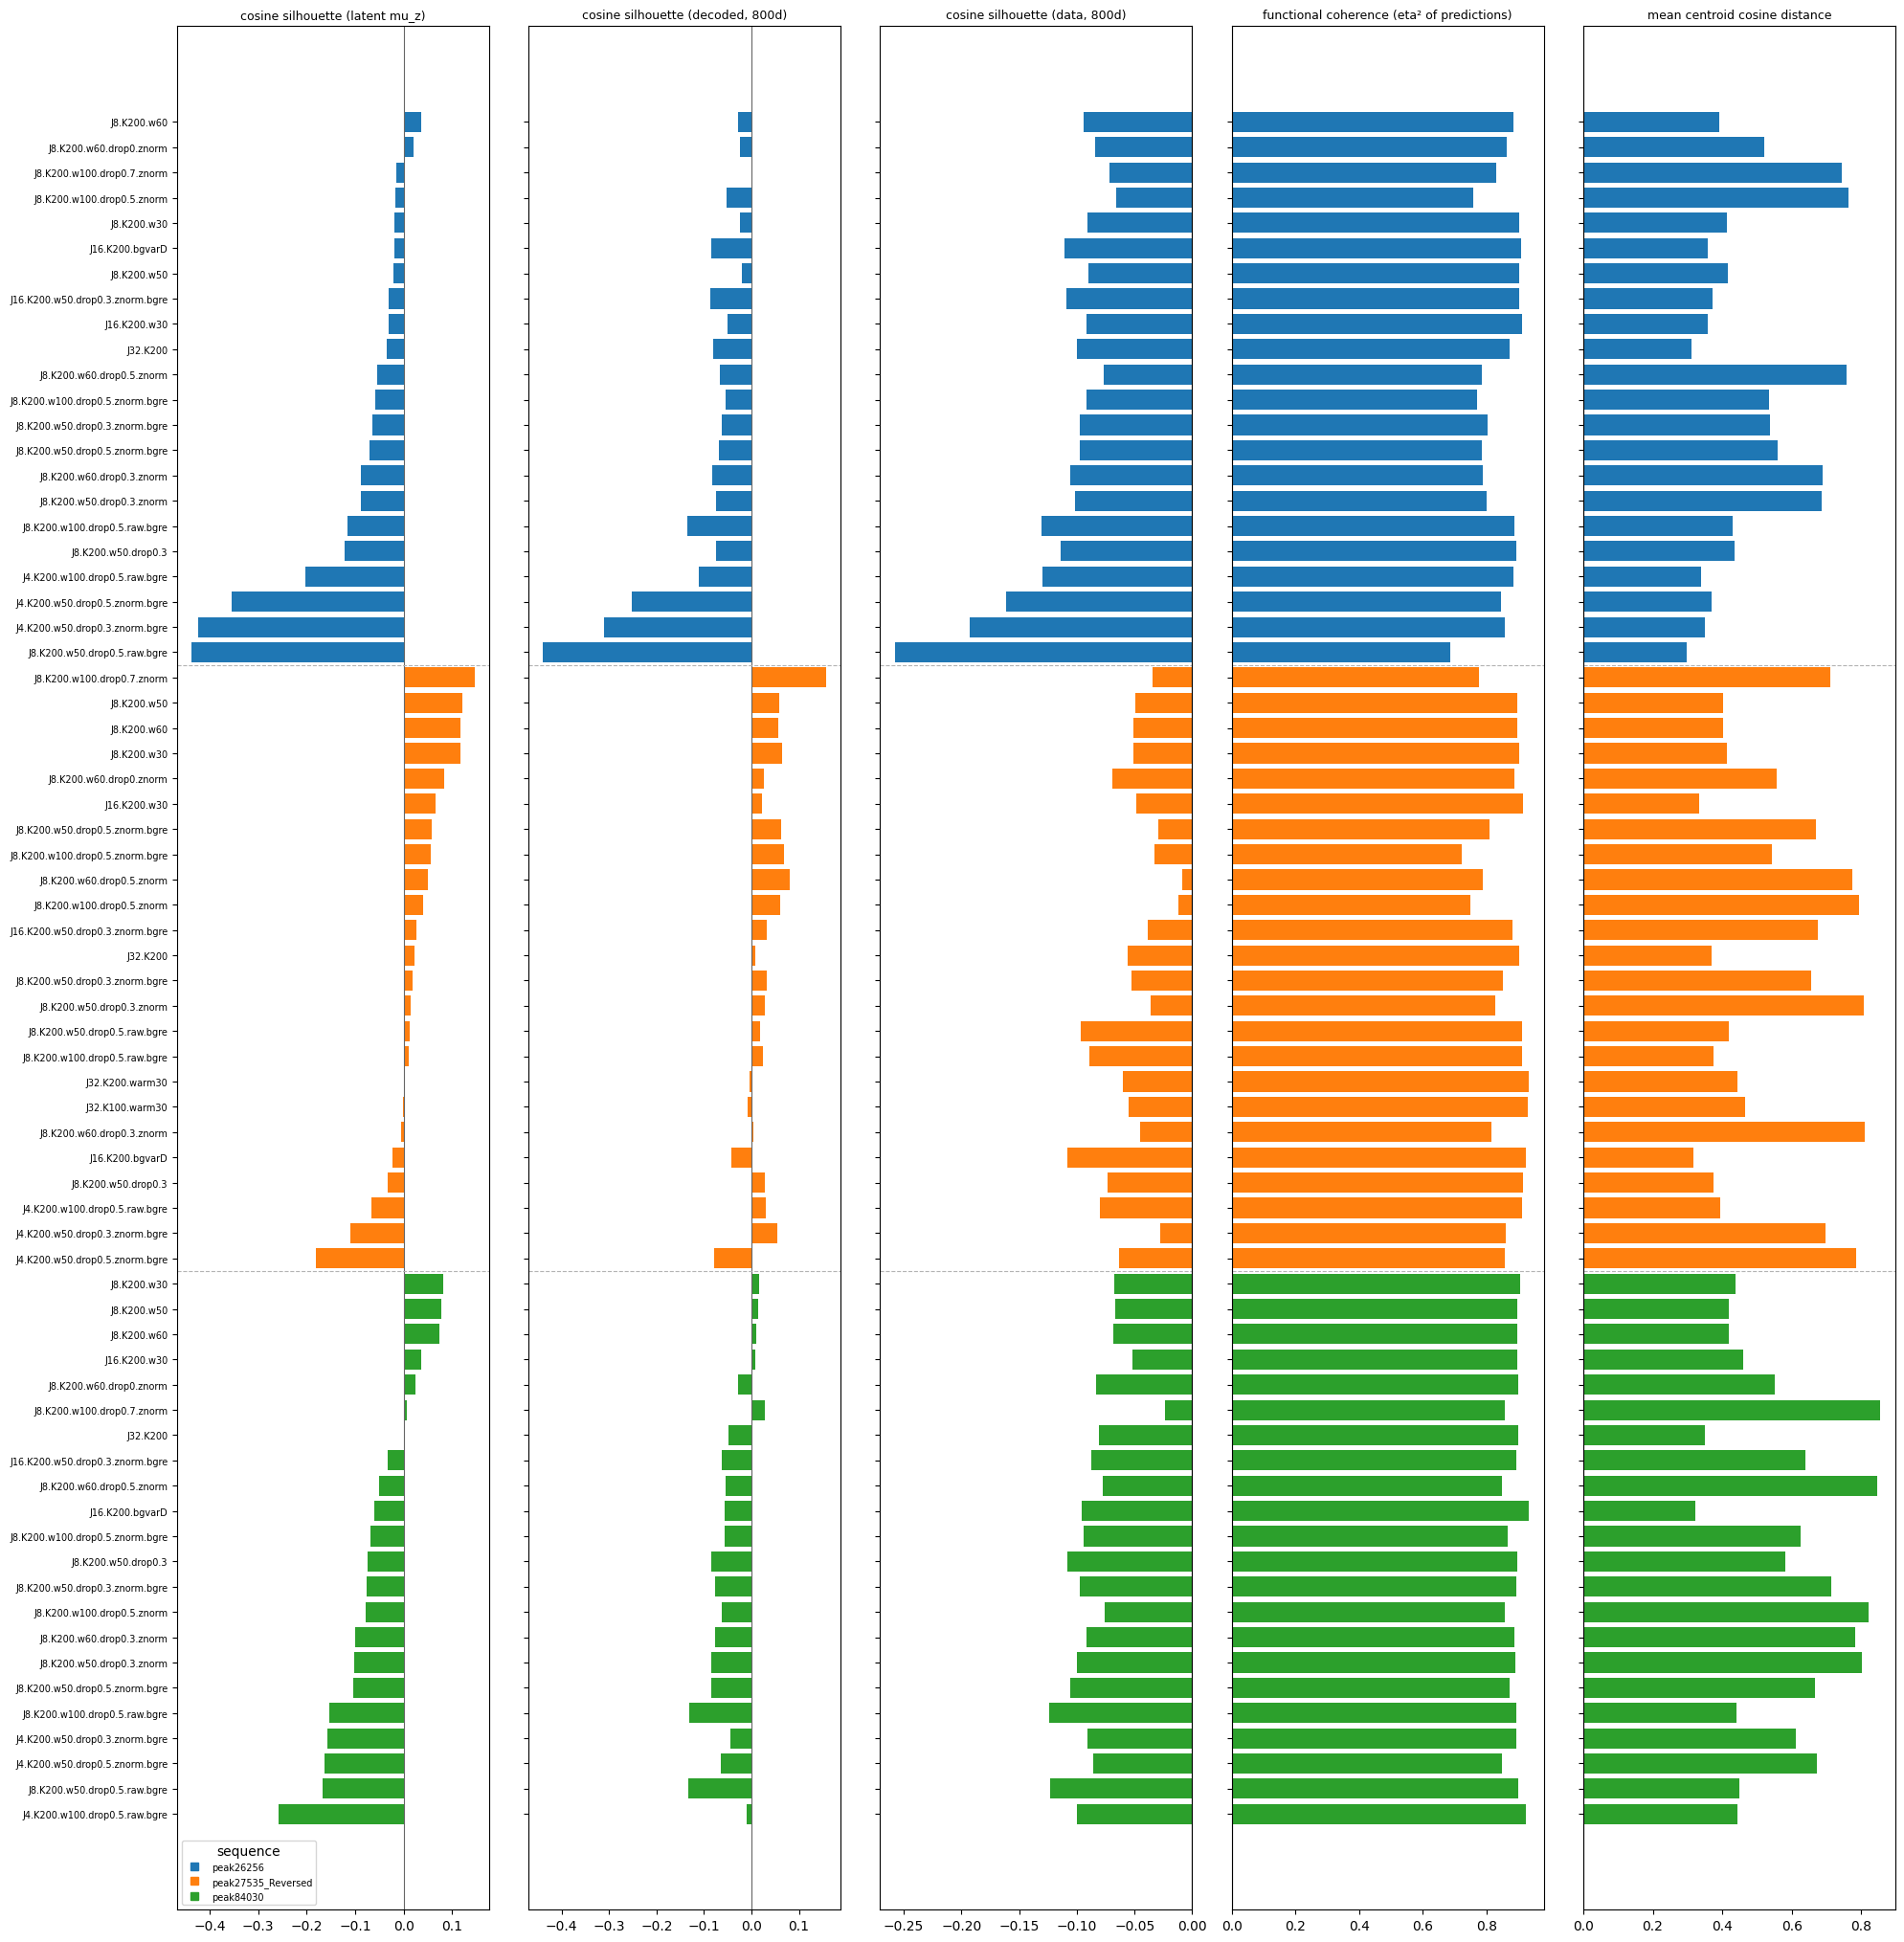

In [22]:
peaks = list(dict.fromkeys(df["peak"]))
_base = plt.get_cmap("tab10").colors
assert len(peaks) <= len(_base), "extend palette (never recycle colors)"
PEAK_COLOR = {p: _base[i] for i, p in enumerate(peaks)}
colors = df["peak"].map(PEAK_COLOR)
ypos = np.arange(len(df))[::-1]

panels = [("sil_cos", "cosine silhouette (latent mu_z)"),
          ("sil_cos_dec", "cosine silhouette (decoded, 800d)"),
          ("sil_cos_800d", "cosine silhouette (data, 800d)"),
          ("func_eta2", "functional coherence (eta² of predictions)"),
          ("centroid_dist_mean", "mean centroid cosine distance")]
fig, axes = plt.subplots(1, len(panels), figsize=(20, max(4, 0.3 * len(df))), sharey=True)
for ax, (col, title) in zip(axes, panels):
    ax.barh(ypos, df[col], color=colors)
    ax.set_title(title, fontsize=9)
    ax.axvline(0, color="0.4", lw=0.8)
axes[0].set_yticks(ypos); axes[0].set_yticklabels(df["short"], fontsize=7)
axes[0].legend(handles=[plt.Line2D([0], [0], marker="s", ls="", color=PEAK_COLOR[p], label=p) for p in peaks],
               title="sequence", fontsize=7, loc="lower left")
for e in np.where(df["peak"].values[1:] != df["peak"].values[:-1])[0]:
    for ax in axes:
        ax.axhline(ypos[e] - 0.5, color="0.7", lw=0.8, ls="--")
fig.tight_layout()
fig.savefig("results/quant_benchmark.png", dpi=300, bbox_inches="tight")
plt.show()